# Ajuste de Distribuciones Beta para Signos Vitales en PhysioNet

Este notebook carga el dataset **PhysioNet Challenge 2019**, extrae las 5 variables de signos vitales clave:

- `HR` (Heart Rate / Frecuencia Cardíaca)
- `SBP` (Systolic Blood Pressure / Presión Arterial Sistólica)
- `MAP` (Mean Arterial Pressure / Presión Arterial Media)
- `Resp` (Respiration Rate / Frecuencia Respiratoria)
- `Temp` (Temperature / Temperatura)

A continuación, limpia los valores nulos, escala los datos al intervalo $[0, 1]$ mediante Min-Max Scaling y ajusta una **distribución Beta estándar** a cada variable para extraer los parámetros de forma (shape parameters) $\alpha$ (alpha) y $\beta$ (beta). Finalmente, grafica los histogramas de frecuencia real junto con la curva teórica ajustada.


In [ ]:
import sys
from pathlib import Path

# Agregar la raíz del código fuente para permitir la importación de 'darl'
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from darl.data.get_dataset import load_dataset
from darl.data.profiling import beta_distribution
from darl.visualization.plots import plot_beta_distributions, save_plot_to_figures

In [2]:
print("Cargando dataset PhysioNet...")
dset = load_dataset(dataset_name="physionet")
df_train, _, _, _ = dset.get_pandas(split="train")
print(f"¡Cargado con éxito! Filas: {df_train.shape[0]}, Columnas: {df_train.shape[1]}")

Cargando dataset PhysioNet...


c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1590: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  df_row = df_row.select_dtypes(
c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1590: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  df_row = df_row.select_dtypes(


¡Cargado con éxito! Filas: 1122299, Columnas: 40


In [15]:
vitals = ["HR", "SBP", "MAP", "Resp", "Temp"]
results = {}

for col in vitals:
    α, β, data_clean, _, col_min, col_max = beta_distribution(df_train, col)

    results[col] = {
        "α": α,
        "β": β,
        "Mínimo Original": col_min,
        "Máximo Original": col_max,
        "Observaciones No Nulas": len(data_clean),
        "% Disponibilidad": (len(data_clean) / len(df_train)) * 100,
    }

df_results = pd.DataFrame(results).T
df_results

,α,β,Mínimo Original,Máximo Original,Observaciones No Nulas,% Disponibilidad
HR,10.236907,31.135223,20.0,280.0,1008302.0,89.842546
SBP,12.446566,20.753380,20.0,296.0,957004.0,85.271750
MAP,11.394786,39.826789,20.0,300.0,979023.0,87.233705
Resp,9.386031,43.394863,1.0,100.0,947102.0,84.389454
Temp,189.440773,153.773402,20.9,50.0,380338.0,33.889186


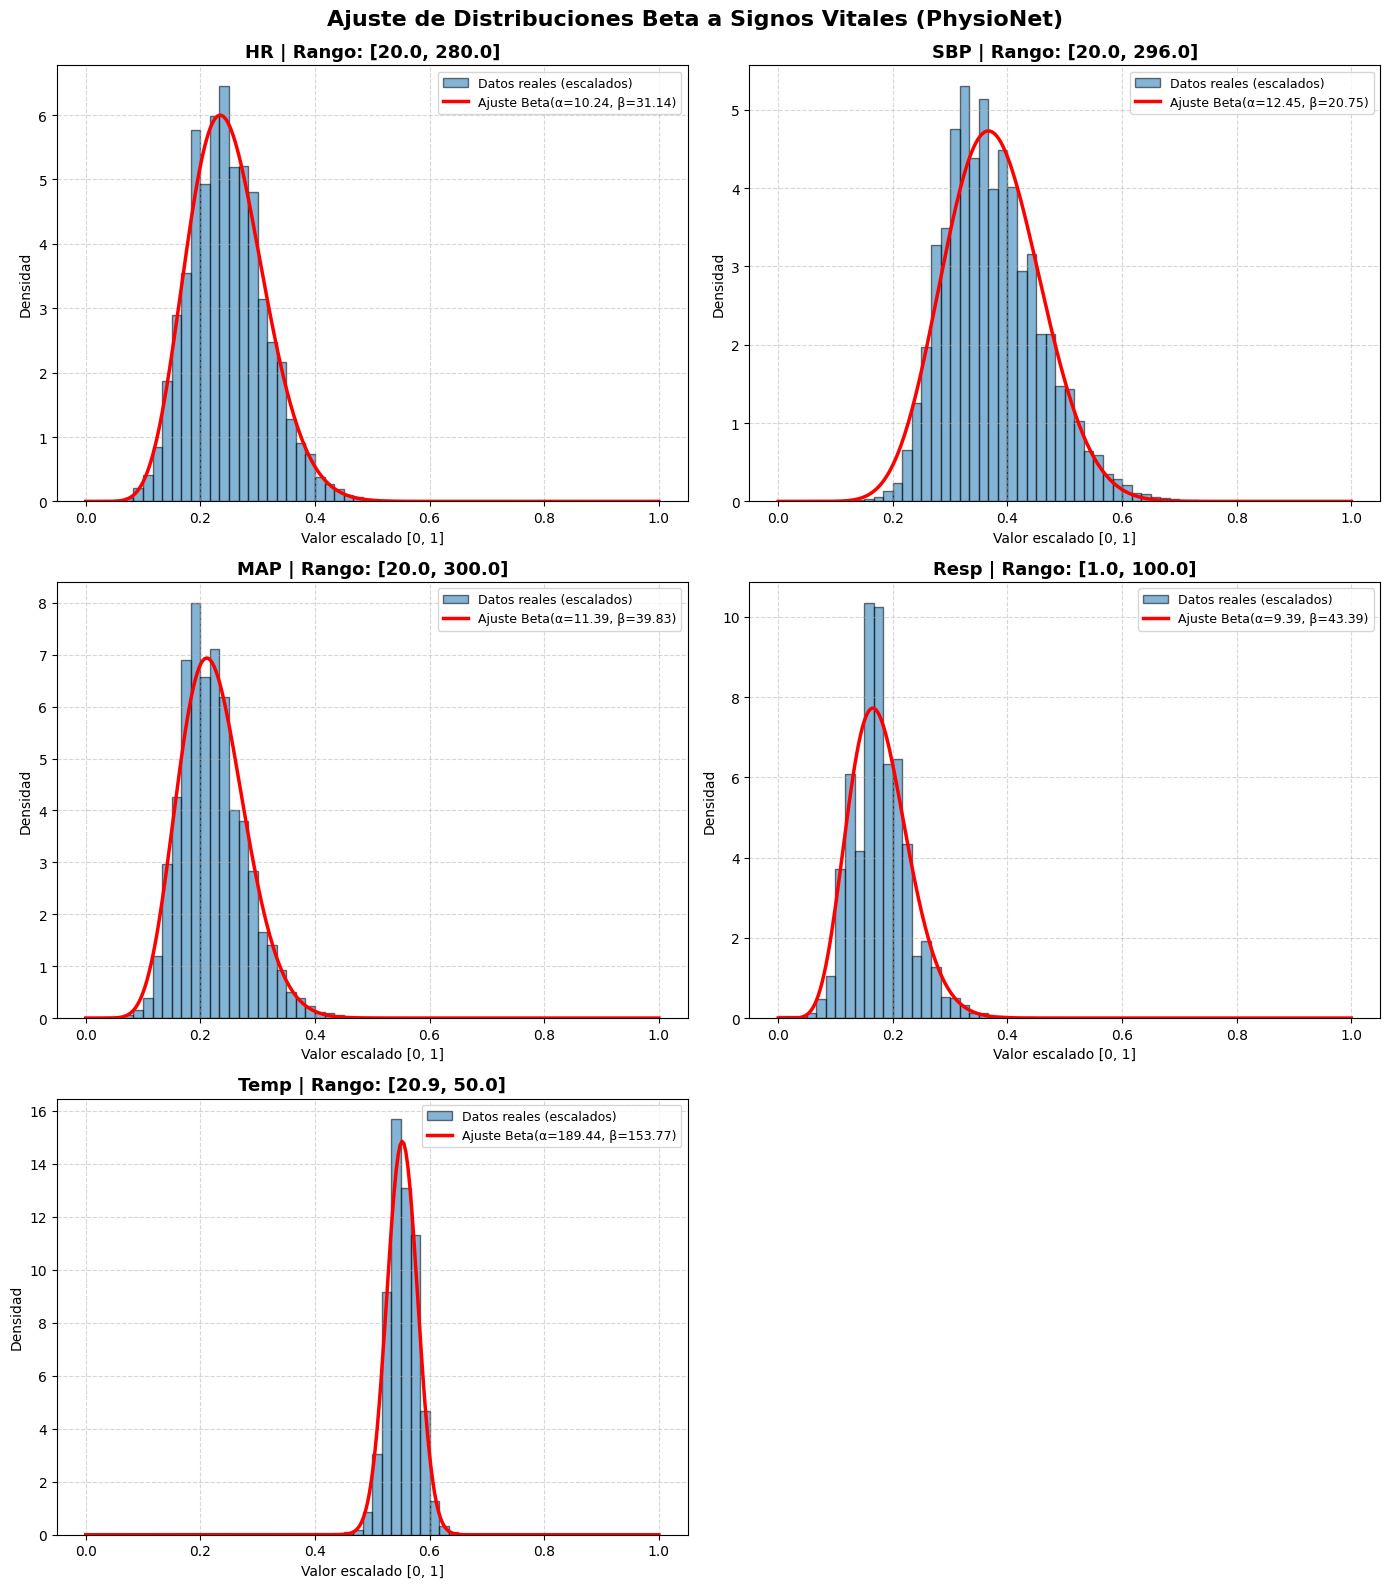

In [18]:
fig = plot_beta_distributions(df_train, vitals)

In [ ]:
save_plot_to_figures(fig, "physionet_beta_distribution.png")